In [32]:
import numpy as np
import matplotlib.pyplot as plt

#np.random.seed(42)

In [33]:
time_step = 1/16
state_action_step = 1/4


time = np.arange(0,1.0, time_step, dtype = float)
print(time)
n_time_steps = len(time)

T = n_time_steps

state_space = np.arange(-1.5, 2.00, state_action_step, dtype = float)
action_space = np.arange(-2.5, 1.25, state_action_step, dtype= float)


print(state_space)
print(action_space)
Q = np.zeros([len(time), len(state_space), len(action_space)], dtype = float)
num_episodes = 1000000
eps = 0.1

c_alpha = 1
x_state = 2
gamma = 1.75
c_g = 0.3



x_vol = 0.5
sigma_0 = 0.5

om_q = 0.55
om_mu = 0.85

mu = np.ones([n_time_steps, len(state_space), len(action_space)]) / (len(state_space) * len(action_space))
mu_history = [[] for _ in range(T)]

jump = round(num_episodes / 1000)


[0.     0.0625 0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625
 0.625  0.6875 0.75   0.8125 0.875  0.9375]
[-1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75  1.    1.25
  1.5   1.75]
[-2.5  -2.25 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25
  0.5   0.75  1.  ]


In [34]:


def state_discretize(x):

    idx = np.argmin(np.abs(state_space - x))
    
    return np.clip(idx, 0, len(state_space) - 1)

def state_transition(x, alpha, dt=(1/16)):

    drift = alpha * dt 

    diffusion_state = x_vol * np.sqrt(dt) * np.random.randn()

    x_next  = x + drift + diffusion_state

    return x_next

def price_dynamics(s, mean_alpha, dt=(1/16)):

    drift = gamma * mean_alpha * dt 

    diffusion_price = sigma_0 * np.sqrt(dt) * np.random.randn()

    s_next = s + drift + diffusion_price

    return s_next

def c_a(alpha):
    
    '''check with JP if this is the correct function'''

    return (1/2) * c_alpha * np.power(alpha, 2)

def c_x_func(x):
    return (1/2) * x_state * np.power(x, 2)

def get_mean_action(mu, t_idx):
    action_marginal = np.sum(mu[t_idx], axis=0)
    return np.dot(action_space, action_marginal)

def immediate_costs(x_val, alpha_val, t_idx, mu, dt=1/16):
    mean_alpha = get_mean_action(mu, t_idx)
    cost = (c_a(alpha_val) + c_x_func(x_val)) - gamma * x_val * mean_alpha
    return cost * dt 

def rhosCalc(count_txa, k):
    '''does this have a counter incrementing?'''
    rhoQ = 1 / np.power(1 + count_txa, om_q)
    rhoMu = 1 / np.power(1 + k, om_mu)
    return { 'q': rhoQ, 'mu': rhoMu }

n_actions = len(action_space)

def epsilon_greedy_action(q_values):
    if np.random.rand() < eps:
        return np.random.randint(0, len(action_space))
    else:
        return np.argmin(q_values)


# initialize count for finding rho_Q (learning rate)
count_txa = np.zeros([T, len(state_space), len(action_space)])

mu_prev = mu.copy()




In [35]:

for k in range(1, num_episodes+1):
    x = np.random.uniform(state_space.min(), state_space.max())
    for t_idx in range(T):
        
        x_idx = state_discretize(x)
        action_idx = epsilon_greedy_action(Q[t_idx, x_idx, :])
        alpha_val = action_space[action_idx]

        count_txa[t_idx, x_idx, action_idx] += 1
        rho_Q = 1 / np.power(1 + count_txa[t_idx, x_idx, action_idx], om_q)
        rho_Mu = 1 / np.power(1 + k, om_mu)

        delta = np.zeros((len(state_space), len(action_space)))
        delta[x_idx, action_idx] = 1.0
        mu[t_idx] += rho_Mu * (delta - mu[t_idx])

        cost_t = immediate_costs(x, alpha_val, t_idx, mu)

        next_x = state_transition(x, alpha_val)
        next_x = np.clip(next_x, state_space.min(), state_space.max())
        
        x_next_idx = state_discretize(next_x)

        if t_idx < T - 1:
            td_target = cost_t + np.min(Q[t_idx + 1, x_next_idx, :])
        else:
            td_target = cost_t + (c_g / 2) * (next_x ** 2)

        Q[t_idx, x_idx, action_idx] += rho_Q * (td_target - Q[t_idx, x_idx, action_idx])

        x = next_x

 
    if (k + 1) % jump == 0:
        for t_idx in range(T):
            mu_history[t_idx].append(get_mean_action(mu, t_idx))

KeyboardInterrupt: 

<Figure size 1500x500 with 0 Axes>

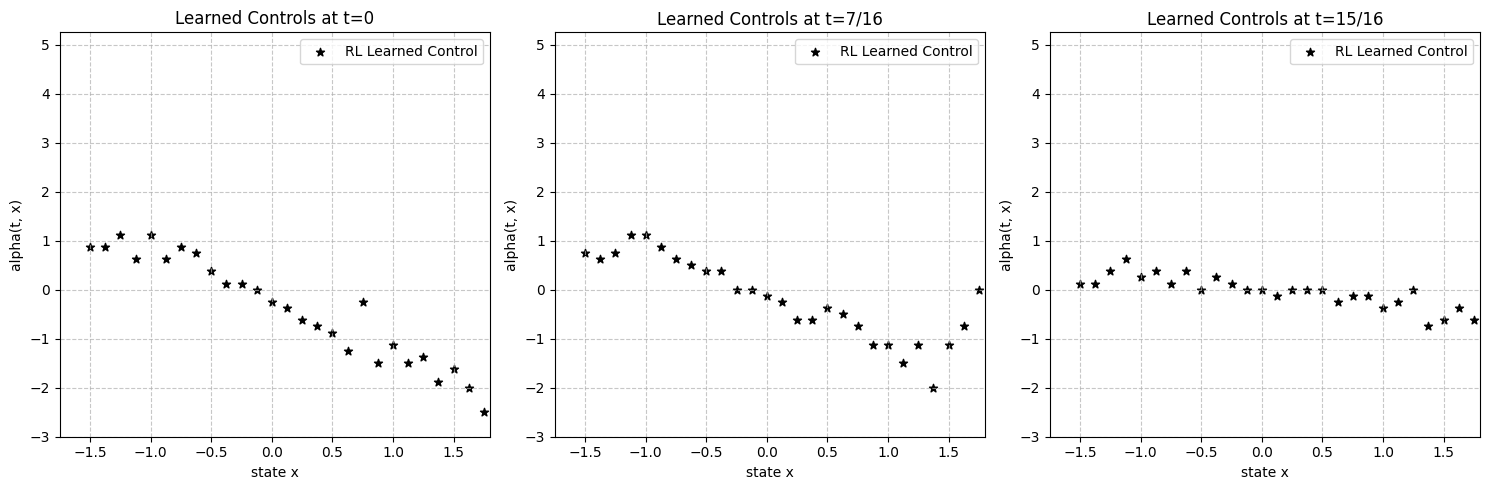

In [ ]:

plt.figure(figsize=(15, 5))
x_range = np.linspace(-2,2, 1000000)

def op_control_0(x):
    return -(1.309571555*x+(2.309085513-1.309571555)*0.5)

def op_control_7(x):
    return -(1.083475891*x+(1.737935738-1.083475891)*(0.5*np.power(np.e, -0.760346885375)))

def op_control_15(x):
    return -(0.4168792984*x+(0.4572735727-0.4168792984)*(0.5*np.power(np.e, -0.42869397440625)))


target_times = [0, 7, 15]
labels = ["t=0", "t=7/16", "t=15/16"]

theoretical_controls = [op_control_0, op_control_7, op_control_15]

plt.figure(figsize=(15, 5))
x_range = np.linspace(-2, 2, 1000)

for i, t_idx in enumerate(target_times):

    optimal_actions = []
    for x_idx in range(len(state_space)):
        best_a_idx = np.argmin(Q[t_idx, x_idx, :])
        optimal_actions.append(action_space[best_a_idx])

    plt.subplot(1, 3, i+1)
    
    # RL control
    plt.scatter(state_space, optimal_actions, 
                color='black', marker='*', label='RL Learned Control')
    
    # Correct theoretical curve for that time
    #plt.plot(x_range, theoretical_controls[i](x_range),
             #color='red', linewidth=2, label='Theoretical Control')

    plt.title(f"Learned Controls at {labels[i]}")
    plt.xlabel("state x")
    plt.ylabel("alpha(t, x)")
    plt.xlim(-1.75, 1.8)
    plt.ylim(-3, 5.25)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

plt.tight_layout()
plt.show()

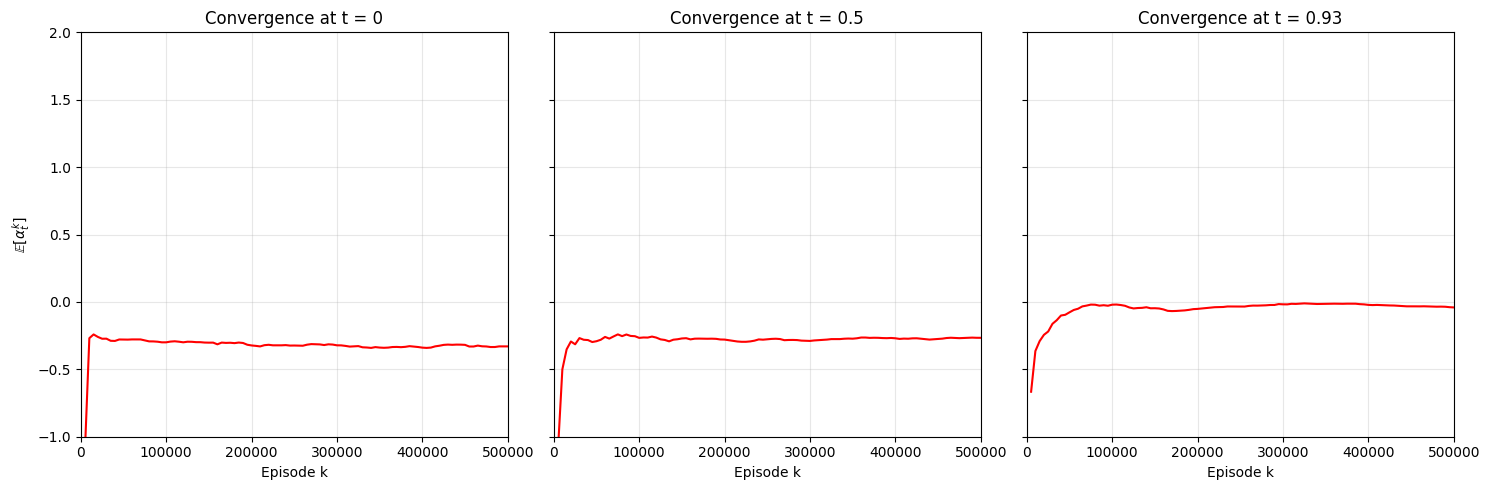

In [ ]:
target_times = [0, 7, 15] 
labels = ["t = 0", "t = 0.5", "t = 0.93"]
jump = 5000 

# Define a shared Y-axis range based on your action space
# This ensures "the same scale"
y_min, y_max = action_space.min(), action_space.max()

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, (idx, label) in enumerate(zip(target_times, labels)):
    ax = axes[i]
    
    # Calculate episode steps for the x-axis
    episodes = np.arange(1, len(mu_history[idx]) + 1) * jump
    
    # Plot RL Learned Mean Field 
    ax.plot(episodes, mu_history[idx], 'r-', linewidth=1.5, label=f'RL Mean at {label}')
    
    # Formatting
    ax.set_xlabel("Episode k")
    if i == 0:
        ax.set_ylabel(r"$\mathbb{E}[\alpha_t^k]$")
    
    ax.set_title(f"Convergence at {label}")
    ax.set_xlim(0, num_episodes)
    ax.set_ylim(-1, 2) # Setting the shared scale
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 1500x500 with 0 Axes>

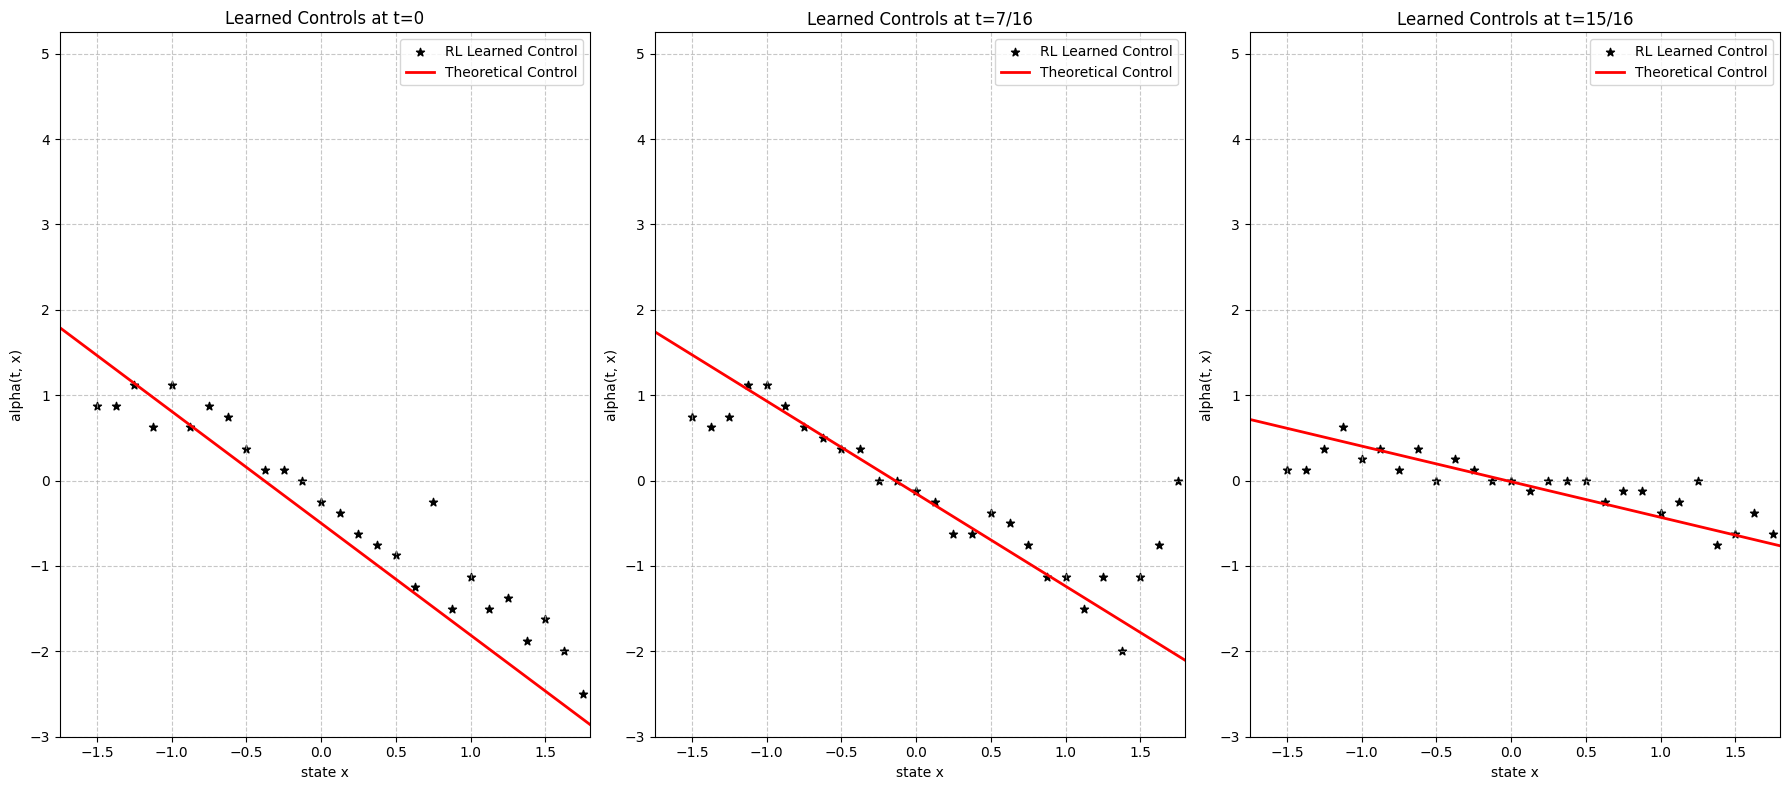

In [ ]:
plt.figure(figsize=(15, 5))
x_range = np.linspace(-2, 2, 1000000)

def op_control_0(x):
    return -(1.309571555*x+(2.309085513-1.309571555)*0.5)

def op_control_7(x):
    return -(1.083475891*x+(1.737935738-1.083475891)*(0.5*np.power(np.e, -0.760346885375)))

def op_control_15(x):
    return -(0.4168792984*x+(0.4572735727-0.4168792984)*(0.5*np.power(np.e, -0.42869397440625)))

target_times = [0, 7, 15]
labels = ["t=0", "t=7/16", "t=15/16"]
theoretical_controls = [op_control_0, op_control_7, op_control_15]

plt.figure(figsize=(18, 8))
x_range = np.linspace(-2, 2, 1000)

# Gaussian weights from initial distribution N(0.5, 0.3^2)
weights = np.exp(-0.5 * ((state_space - 0.5) / 0.3)**2)
weights /= weights.sum()

for i, t_idx in enumerate(target_times):

    optimal_actions = []
    for x_idx in range(len(state_space)):
        best_a_idx = np.argmin(Q[t_idx, x_idx, :])
        optimal_actions.append(action_space[best_a_idx])

    optimal_actions = np.array(optimal_actions)
    theory = theoretical_controls[i](state_space)

    # RMSE calculations
    rmse = np.sqrt(np.mean((optimal_actions - theory)**2))
    rmse_weighted = np.sqrt(np.sum(weights * (optimal_actions - theory)**2))

    plt.subplot(1, 3, i+1)
    
    plt.scatter(state_space, optimal_actions, 
                color='black', marker='*', label='RL Learned Control')
    plt.plot(x_range, theoretical_controls[i](x_range),
             color='red', linewidth=2, label='Theoretical Control')

    plt.title(f'Learned Controls at {labels[i]}')
    plt.xlabel("state x")
    plt.ylabel("alpha(t, x)")
    plt.xlim(-1.75, 1.8)
    plt.ylim(-3, 5.25)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
plt.savefig("Learned Controls.pdf", dpi=800, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
for t_idx in [0, 7, 15]:
    marginal = np.sum(mu[t_idx], axis=0)  # sum over states
    print(f"t={t_idx}: marginal sums to {marginal.sum():.4f}, mean = {np.dot(action_space, marginal):.4f}")

t=0: marginal sums to 1.0000, mean = -0.4936
t=7: marginal sums to 1.0000, mean = -0.1901
t=15: marginal sums to 1.0000, mean = -0.0373


In [ ]:
print(mu)

[[[6.75942925e-05 5.90720599e-05 5.05756278e-05 ... 2.27195314e-03
   1.76942618e-04 1.72858686e-04]
  [1.53227552e-04 1.23362914e-04 5.93260994e-05 ... 3.19196633e-02
   1.55058952e-04 9.79368408e-05]
  [1.51420101e-04 7.61336428e-05 1.14709892e-04 ... 3.59939000e-04
   2.32456399e-04 3.25535522e-02]
  ...
  [1.08307892e-04 2.60270281e-03 1.59374100e-04 ... 1.40111029e-04
   1.49476807e-04 8.48380794e-05]
  [2.84319723e-02 1.01291791e-03 1.29979249e-04 ... 1.07979897e-04
   1.19952688e-04 1.81361339e-04]
  [1.42490922e-03 8.28456334e-05 8.21049752e-03 ... 7.84284501e-05
   5.61033555e-05 1.00795295e-04]]

 [[1.03749753e-04 6.31833592e-05 9.35415748e-05 ... 7.98292276e-04
   9.44725386e-05 9.96534061e-05]
  [8.96107104e-05 7.32843541e-05 9.26944328e-05 ... 1.96426386e-04
   6.58442518e-03 1.42724147e-02]
  [1.46216739e-04 1.20188712e-04 9.24542661e-05 ... 1.83823492e-03
   2.84658393e-02 5.74976882e-04]
  ...
  [2.31352295e-04 1.15089672e-03 6.67444369e-04 ... 7.02042879e-05
   8.12520

In [ ]:
np.savez("mfg_controls.npz",
         state_space=state_space,
         t0=pi_0 @ action_space,
         t7=pi_7 @ action_space,
         t15=pi_15 @ action_space)

In [ ]:
np.savez("rl_controls.npz",
         state_space=state_space,
         t0=ctrl_0,
         t7=ctrl_7,
         t15=ctrl_15)